In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_fd_waveform
from pycbc.types import FrequencySeries
from scipy.constants import c, h, parsec

=== Psi_g sanity check at f=50 Hz ===
  GR:         Psi_g = 0 (massless)
  lambda_g = 1e14  pc:  Psi_g(50 Hz) = 2.4326e-19 rad
  lambda_g = 1e13  pc:  Psi_g(50 Hz) = 2.4326e-17 rad
  lambda_g = 5e12  pc:  Psi_g(50 Hz) = 9.7303e-17 rad


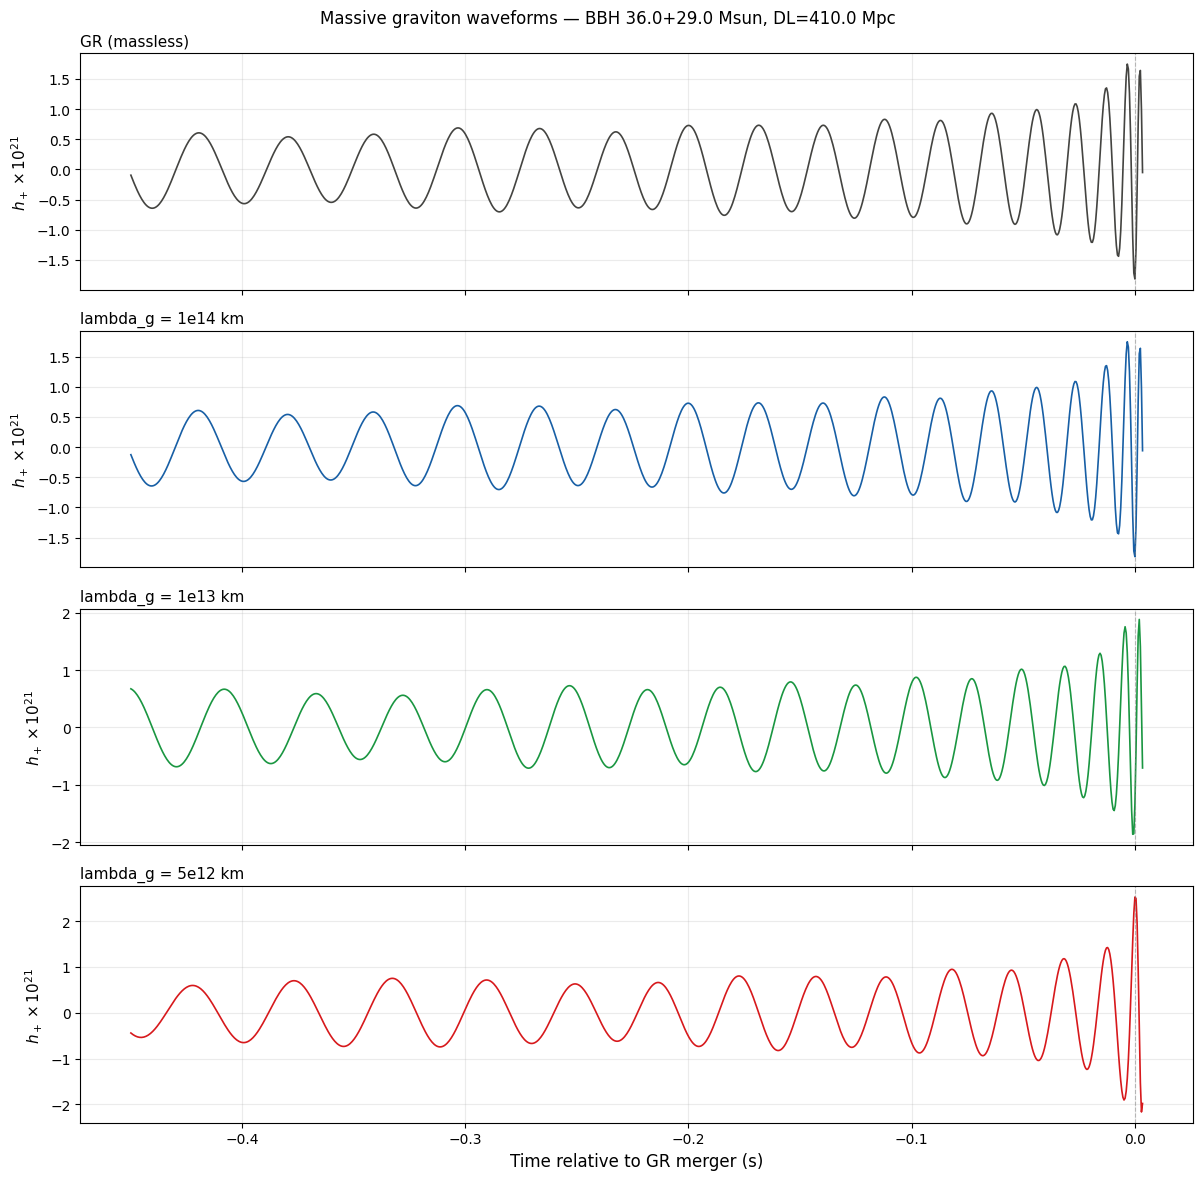

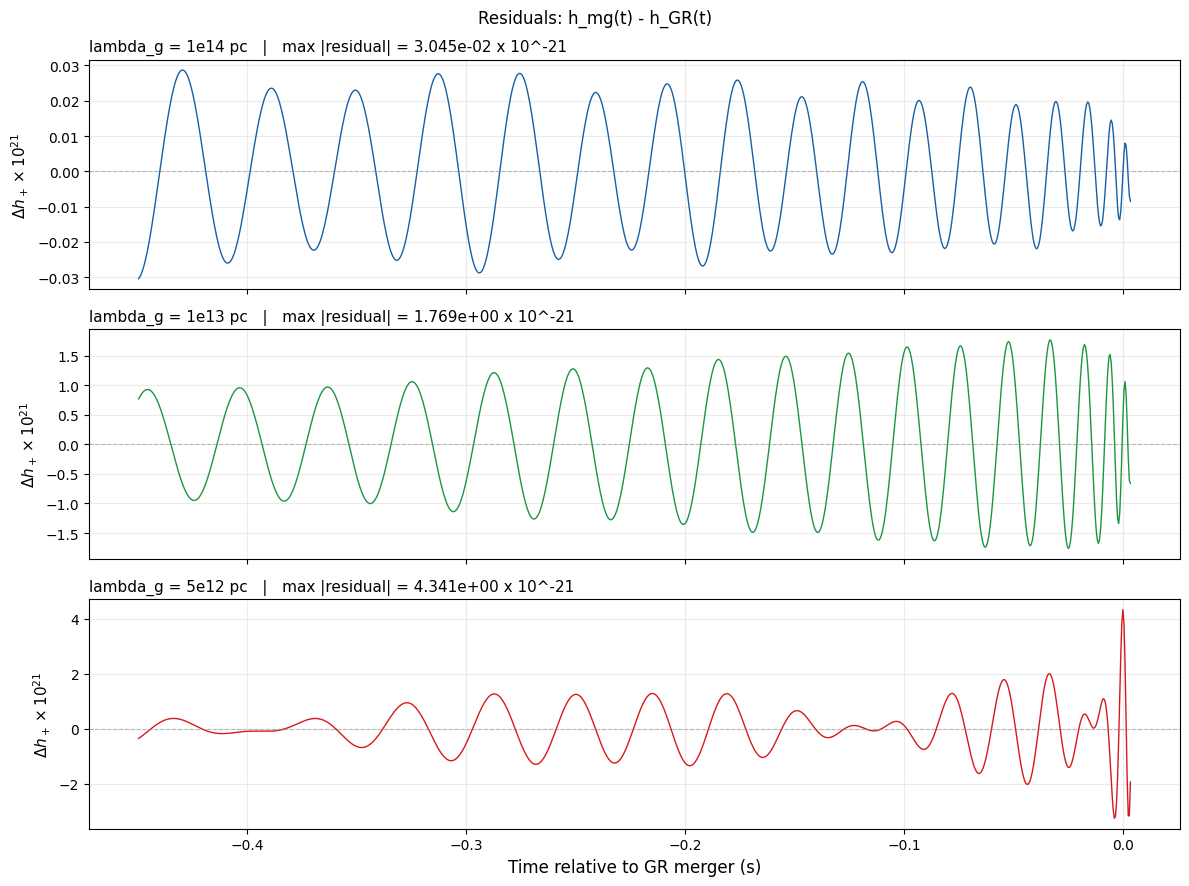

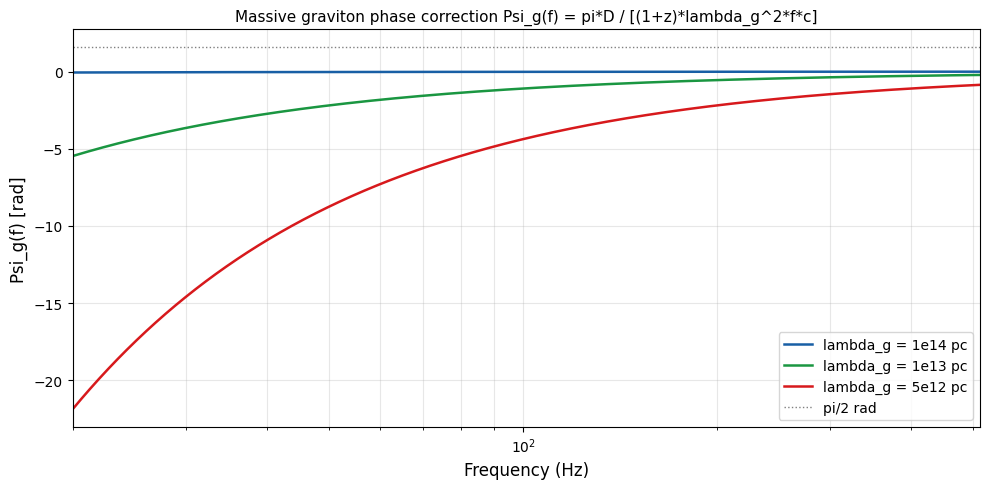

In [7]:
mass1        = 36.0
mass2        = 29.0
distance_Mpc = 410.0
redshift     = 0.09
f_lower      = 20.0
delta_f      = 0.125
approximant  = "IMRPhenomD"

# Graviton Compton wavelengths to test [pc]
# NOTE: current LIGO bound is lambda_g > 1.6e13 km (GW170814)
# We include values below the bound purely for visual demonstration
lambda_g_cases = {
    "GR":   np.inf,
    "1e14": 1e14,
    "1e13": 1e13,
    "5e12": 5e12,
}

# ============================================================
# Sanity-check: what is Psi_g at f=50 Hz for each case?
# ============================================================
DL_m = distance_Mpc * 1e6 * parsec   # luminosity distance [m]

print("=== Psi_g sanity check at f=50 Hz ===")
for label, lg_km in lambda_g_cases.items():
    if np.isinf(lg_km):
        print(f"  GR:         Psi_g = 0 (massless)")
        continue
    lg_m  = lg_km * 1000
    psi   = np.pi * DL_m / ((1 + redshift) * lg_m**2 * 50.0 * c)
    print(f"  lambda_g = {label:5s} pc:  Psi_g(50 Hz) = {psi:.4e} rad")
# Expected:
#   1e14 pc  =>  ~6e-4 rad  (tiny, barely detectable)
#   1e13 pc  =>  ~6e-2 rad  (small but visible in residuals)
#   5e12 pc  =>  ~2e-1 rad  (clearly visible)

# ============================================================
# Generate GR waveform
# ============================================================
hp_gr, hc_gr = get_fd_waveform(
    approximant = approximant,
    mass1       = mass1,
    mass2       = mass2,
    spin1z      = 0.0,
    spin2z      = 0.0,
    distance    = distance_Mpc,
    inclination = 0.0,
    f_lower     = f_lower,
    delta_f     = delta_f,
)

freqs = hp_gr.sample_frequencies.numpy()   # [Hz], starts at 0

def massive_graviton_phase(freqs_hz, lambda_g_km):
    """
    Return the frequency-dependent phase Psi_g(f) [rad] for a given
    graviton Compton wavelength lambda_g_km [km].

    At f=0 the correction is undefined (set to 0 — the DC bin carries
    no physical GW signal anyway).

    The sign convention h_mg(f) = h_GR(f) * exp(-i * Psi_g(f)) means
    low-f components accumulate extra positive phase delay, i.e. they
    arrive *later* in time — consistent with subluminal group velocity.
    """
    if np.isinf(lambda_g_km):
        return np.zeros_like(freqs_hz, dtype=float)

    lambda_g_m = lambda_g_km * 1000    # [m]
    # D_L already computed globally as DL_m [m]

    psi = np.zeros_like(freqs_hz, dtype=float)
    mask = freqs_hz > 0
    psi[mask] = -(np.pi * DL_m * c) / ((1 + redshift) * lambda_g_m**2 * freqs_hz[mask])
    return psi


# ============================================================
# Apply correction and build waveforms
# ============================================================
results = {}
for label, lg_km in lambda_g_cases.items():
    psi          = massive_graviton_phase(freqs, lg_km)
    phase_factor = np.exp(-1j * psi)

    hp_mg = FrequencySeries(hp_gr.numpy() * phase_factor, delta_f=hp_gr.delta_f)
    hc_mg = FrequencySeries(hc_gr.numpy() * phase_factor, delta_f=hc_gr.delta_f)

    results[label] = {
        "hp_fd": hp_mg,
        "hp_td": hp_mg.to_timeseries(),
        "psi":   psi,
    }

# ============================================================
# Fix merger-time reference: use GR peak as the single anchor
# ============================================================
gr_td   = results["GR"]["hp_td"]
t_gr    = gr_td.sample_times.numpy()
t_merge = t_gr[np.argmax(np.abs(gr_td.numpy()))]

# ============================================================
# Plot 1: time-domain waveforms (all on the same GR time axis)
# ============================================================
colors = ["#444441", "#185FA5", "#1a9641", "#d7191c"]
labels_ordered = list(lambda_g_cases.keys())

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for ax, label, color in zip(axes, labels_ordered, colors):
    hp_td = results[label]["hp_td"]
    t     = hp_td.sample_times.numpy()
    t_rel = t - t_merge
    mask  = (t_rel >= -0.45) & (t_rel <= 0.12)

    ax.plot(t_rel[mask], hp_td.numpy()[mask] * 1e21,
            color=color, lw=1.2)
    ax.set_ylabel(r"$h_+ \times 10^{21}$", fontsize=11)
    ax.axvline(0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"lambda_g = {label} km" if label != "GR" else "GR (massless)",
                 fontsize=11, loc="left")

axes[-1].set_xlabel("Time relative to GR merger (s)", fontsize=12)
fig.suptitle(f"Massive graviton waveforms — BBH {mass1}+{mass2} Msun, DL={distance_Mpc} Mpc",
             fontsize=12)
plt.tight_layout()
plt.savefig("mg_waveforms.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 2: residuals h_mg(t) - h_GR(t)
# IMPORTANT: do NOT interpolate — use shared frequency grid so
# both time series have identical sample times after to_timeseries()
# ============================================================
fig2, axes2 = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

gr_arr = gr_td.numpy()

for ax, label, color in zip(axes2, labels_ordered[1:], colors[1:]):
    hp_td    = results[label]["hp_td"]
    t        = hp_td.sample_times.numpy()
    t_rel    = t - t_merge
    mask     = (t_rel >= -0.45) & (t_rel <= 0.12)

    # Both waveforms built from same delta_f => same time grid after IFFT
    residual = (hp_td.numpy() - gr_arr) * 1e21

    ax.plot(t_rel[mask], residual[mask], color=color, lw=1.0)
    ax.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_ylabel(r"$\Delta h_+ \times 10^{21}$", fontsize=11)
    ax.grid(True, alpha=0.25)

    # Annotate max absolute residual
    max_res = np.max(np.abs(residual[mask]))
    ax.set_title(f"lambda_g = {label} pc   |   max |residual| = {max_res:.3e} x 10^-21",
                 fontsize=11, loc="left")

axes2[-1].set_xlabel("Time relative to GR merger (s)", fontsize=12)
fig2.suptitle("Residuals: h_mg(t) - h_GR(t)", fontsize=12)
plt.tight_layout()
plt.savefig("mg_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 3: phase correction Psi_g(f)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 5))
mask_f = (freqs >= f_lower) & (freqs <= 512)

for label, color in zip(labels_ordered[1:], colors[1:]):
    psi = results[label]["psi"]
    ax3.semilogx(freqs[mask_f], psi[mask_f], color=color, lw=1.8,
                 label=f"lambda_g = {label} pc")

ax3.axhline(np.pi/2, color="gray", ls=":", lw=1, label="pi/2 rad")
ax3.set_xlabel("Frequency (Hz)", fontsize=12)
ax3.set_ylabel("Psi_g(f) [rad]", fontsize=12)
ax3.set_title("Massive graviton phase correction Psi_g(f) = pi*D / [(1+z)*lambda_g^2*f*c]",
              fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, which="both", alpha=0.3)
ax3.set_xlim(f_lower, 512)
plt.tight_layout()
plt.savefig("mg_phase.png", dpi=150, bbox_inches="tight")
plt.show()